# Paper figures

Fiducial inference setup: $n_\mathrm{train}=10\,000$ cosmologies, $b_x=32$ bias sets per cosmo, noisy (`biasnoisenest`), `_best-rand30` checkpoints.

Fiducial statistics: $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B$; $P_{gg}+B+P_{gm}$.

Results plots use **un-reparameterized** parameters ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$) via `unreparameterize=True` in `plotter`.

In [4]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_model

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# --- Fiducial config ---
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
# pk, pk+pgm, pk+bispec, pk+bispec+pgm
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]

TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

param_names_key, param_names_key_rp = utils_plot.get_param_names_key()
PARAM_NAMES_ZOOM = list(param_names_key)
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]
extents_narrow = extents.copy()
extents_narrow["b1"] = [0.2, 0.7]

FIGSIZE_CORNER = (5, 5)
FIGSIZE_ALL_PARAMS = (9, 9)
FONTSIZE_LEGEND = 12
LOC_LEGEND = (1.02, 0.98)
KMAX_LOOSE = 0.4  # pk-only implicit cut; used in scale-sweep section only
ANOISE_OPTION = "Anmult"

dir_sbi = paths.DIR_RESULTS / "results_sbi"
n_cosmo_max_stats = 100  # subsample for statistics range plots


def setup_fiducial_inference():
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        statistics_arr=STATISTICS_ARR_FID,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=TAGS_MASK_FID,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    return tags_inf, labels, list(COLORS_FID)


def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"


def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]


def setup_fixed_mean_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        TAG_BIASPARAMS_TEST_FIXED,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary


def setup_coverage_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        tag_stats_arr=tag_stats_arr,
        tag_noise_test=TAG_NOISE_TEST_COV,
        tag_datagen_test="",
        tags_mask_test=TAGS_MASK_FID,
    )
    keep = samples_exist(tags_inf, tags_test)
    return tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary


def setup_shame_test():
    tags_inf, labels, colors = setup_fiducial_inference()
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    tag_stats_arr = [f'_{"_".join(s)}' + m for s, m in zip(STATISTICS_ARR_FID, TAGS_MASK_FID)]
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=TAG_MOCK_SHAME,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME)
    theta_obs_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, param_vary, theta_obs_full[idxs_zoom]


def plot_fiducial_contours(tags_inf, labels, colors, tags_test, keep, title, theta_show, *, extents=None):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print(f"No samples on disk for: {title}")
        for i, k in enumerate(keep):
            if not k:
                print(f"  missing: {sample_fn(tags_inf[i], tags_test[i])}")
        return
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=title,
        extents=extents or extents_mid,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )


def stats_summary(arr):
    return (
        np.nanmean(arr, axis=0),
        np.nanpercentile(arr, 16, axis=0),
        np.nanpercentile(arr, 84, axis=0),
    )


def plot_stat_band(ax, x, mean, p16, p84, color, label):
    ax.fill_between(x, p16, p84, color=color, alpha=0.2, label=f"{label} (16–84%)")
    ax.plot(x, mean, color=color, label=f"{label} (mean)")

## 1. mMocks overview

Pipeline: initial conditions → map2map displacement → Eulerian bias fields → biased tracer overdensity field.

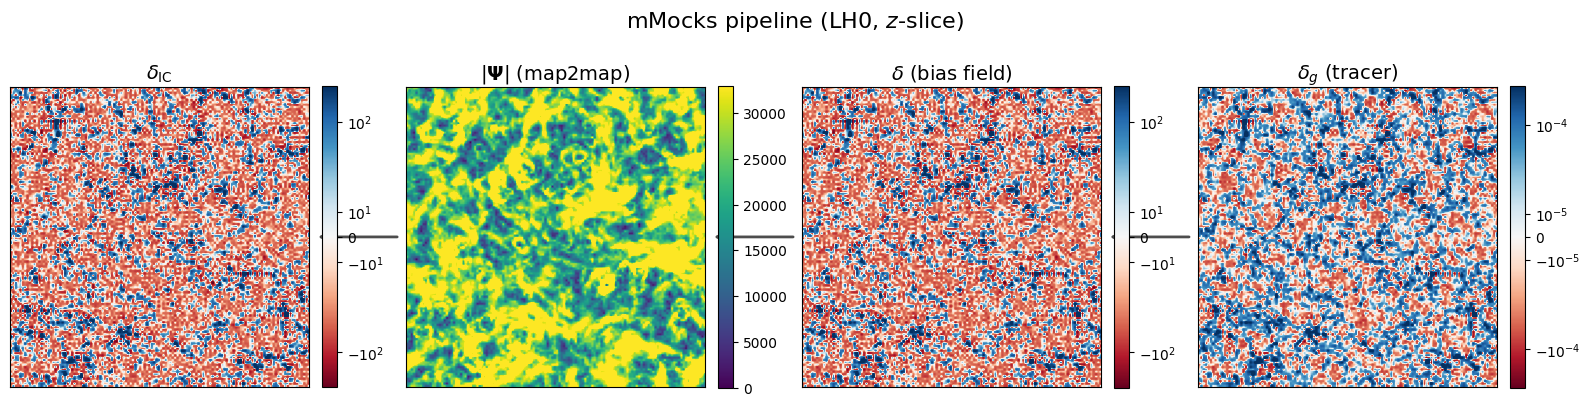

In [6]:
idx_mock = 0
dir_mocks = paths.mocks_lib_dir(TAG_PARAMS_TRAIN)
subdir = f"LH{idx_mock}"
mock_dir = dir_mocks / subdir
fn_bias = mock_dir / f"bias_fields_eul_deconvolved_{idx_mock}.npy"
fn_vel = mock_dir / "pred_vel_kcut.npy"
if not fn_bias.is_file():
    print(f"Skipping overview: missing {fn_bias}")
else:
    bias_terms = np.load(fn_bias)
    n_grid = bias_terms.shape[-2]
    z_slice = bias_terms.shape[-1] // 2

    delta_ic = bias_terms[1, :, :, z_slice]  # linear density / matter field
    bias_delta = bias_terms[1, :, :, z_slice]

    if fn_vel.is_file():
        pred_vel = np.load(fn_vel, mmap_mode="r")
        disp_mag = np.sqrt(np.sum(pred_vel[:, :, :, z_slice] ** 2, axis=0))
    else:
        print(f"Warning: missing {fn_vel}; using |δ| as map2map placeholder")
        disp_mag = np.abs(bias_delta)

    _, _, biasparams_df, _, _, _ = data_loader.load_params(TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx)
    bias_vector = biasparams_df.iloc[idx_mock * bx][utils_model.biasparam_names_ordered].values
    tracer = utils_model.get_tracer_field(
        bias_terms, bias_vector, n_grid_norm=n_grid,
    )
    tracer_slice = tracer[:, :, z_slice]

def _imshow_field(ax, field, title, *, overdensity=True):
    vmax = 3 * np.std(field)
    vmin = -vmax if overdensity else np.min(field[field > 0])
    if overdensity:
        from matplotlib.colors import SymLogNorm
        norm = SymLogNorm(linthresh=0.1 * vmax, vmin=vmin, vmax=vmax)
        cmap = "RdBu"
    else:
        norm = plt.Normalize(vmin=0, vmax=vmax)
        cmap = "viridis"
    im = ax.imshow(field, norm=norm, cmap=cmap, origin="lower")
    ax.set_title(title, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

panels = [
    (delta_ic, r"$\delta_\mathrm{IC}$", True),
    (disp_mag, r"$|\mathbf{\Psi}|$ (map2map)", False),
    (bias_delta, r"$\delta$ (bias field)", True),
    (tracer_slice, r"$\delta_g$ (tracer)", True),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (field, title, symlog) in zip(axes, panels):
    _imshow_field(ax, field, title, overdensity=symlog)
for i in range(len(axes) - 1):
    axes[i].annotate(
        "",
        xy=(1.02, 0.5),
        xycoords="axes fraction",
        xytext=(-0.02, 0.5),
        textcoords=axes[i + 1].transAxes,
        arrowprops=dict(arrowstyle="->", lw=2, color="0.3"),
    )
fig.suptitle(f"mMocks pipeline (LH{idx_mock}, $z$-slice)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 2. Statistics: training-set ranges

Mean and 16–84% bands over the fiducial noisy training set ($n_\mathrm{cosmo}\leq 100$ subsample).

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pks in /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Found 10000 diff cosmo pgms in /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnoisenest_p9_n320000_noise

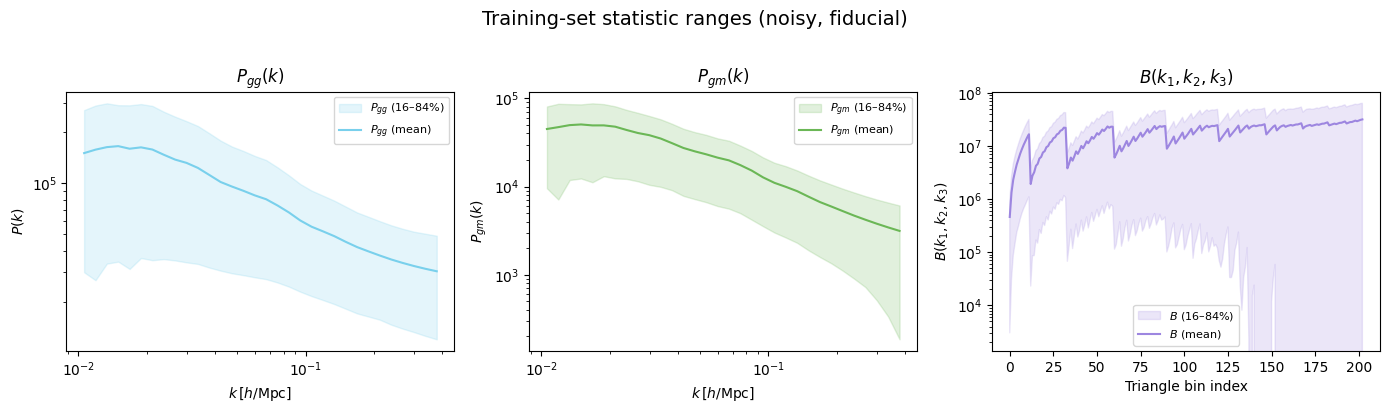

In [7]:
COLOR_STAT = {"pk": COLORS_FID[0], "pgm": COLORS_FID[1], "bispec": COLORS_FID[2]}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# P(k)
k_pk, pks, _, _ = data_loader.load_data_muchisimocks(
    "pk", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_pk, p16_pk, p84_pk = stats_summary(pks)
plot_stat_band(axes[0], k_pk, mean_pk, p16_pk, p84_pk, COLOR_STAT["pk"], "$P_{gg}$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$"); axes[0].set_ylabel(r"$P(k)$")
axes[0].set_title(r"$P_{gg}(k)$"); axes[0].legend(fontsize=8)

# P_gm(k)
k_pgm, pgms, _, _ = data_loader.load_data_muchisimocks(
    "pgm", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_pgm, p16_pgm, p84_pgm = stats_summary(pgms)
plot_stat_band(axes[1], k_pgm, mean_pgm, p16_pgm, p84_pgm, COLOR_STAT["pgm"], "$P_{gm}$")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"$k\,[h/\mathrm{Mpc}]$"); axes[1].set_ylabel(r"$P_{gm}(k)$")
axes[1].set_title(r"$P_{gm}(k)$"); axes[1].legend(fontsize=8)

# Bispectrum (triangle bin index; matches 2026-03-10_load_statistics)
_, bispecs, _, _ = data_loader.load_data_muchisimocks(
    "bispec", TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN, bx=bx, n_cosmo_max=n_cosmo_max_stats,
)
mean_b, p16_b, p84_b = stats_summary(bispecs)
x_b = np.arange(len(mean_b))
plot_stat_band(axes[2], x_b, mean_b, p16_b, p84_b, COLOR_STAT["bispec"], "$B$")
axes[2].set_yscale("log")
axes[2].set_xlabel("Triangle bin index"); axes[2].set_ylabel(r"$B(k_1,k_2,k_3)$")
axes[2].set_title(r"$B(k_1,k_2,k_3)$"); axes[2].legend(fontsize=8)

fig.suptitle("Training-set statistic ranges (noisy, fiducial)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Cosmic variance test (fixed cosmology, mean)

Contour plot evaluated on the mean of 1000 fixed-cosmo mocks. All four fiducial statistics combinations.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

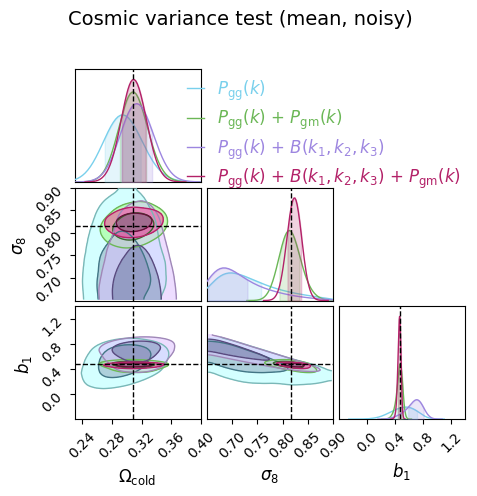

In [8]:
tags_inf, labels, colors, tags_test, keep, _, theta_show, _ = setup_fixed_mean_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    title="Cosmic variance test (mean, noisy)",
    theta_show=theta_show,
    extents=extents_mid,
)

## 4. Coverage test — distributions

Fractional errors and error calibration ($\Delta\theta/\sigma$ vs Gaussian) for $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$. Uses full fiducial stat combo grid (four rows).

fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_coverage_p5_n1000_biasnoisecoverage_p9_n1000_noise_unit_coverage_p5_n1000_pred.npy
fn_samples_test_pred = /scratch/kstoreyf/muchisimocks/results/re

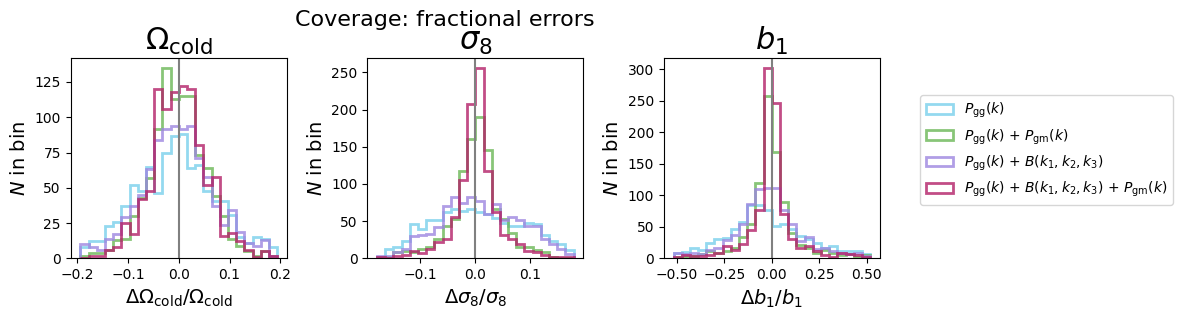

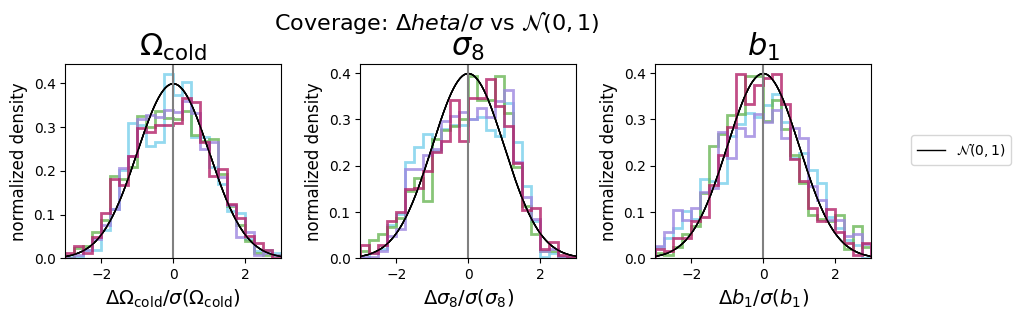

(array([[[ 1.7749412 , -1.49924996,  0.31667457],
         [-0.59340863, -1.44198837,  0.87056121],
         [-0.97378046,  0.69588846, -1.61560984],
         ...,
         [ 0.31661016, -1.36718894,  0.19392396],
         [-1.25426004, -0.24093198, -1.16624145],
         [-0.8739874 ,  1.50916993, -2.21001741]],
 
        [[ 1.07020631, -1.30892051,  0.30658302],
         [-2.19066409, -1.90866012,  0.23295051],
         [ 0.45988109,  0.1245974 ,  0.00806618],
         ...,
         [ 0.46454117, -1.72224485,  0.79323779],
         [-0.08983466,  0.23766002, -0.17373739],
         [ 0.18843747, -0.75954389,  0.77117253]],
 
        [[ 0.51050694, -0.69408973,  0.23748397],
         [-0.76660891, -1.50308113,  0.76625849],
         [-0.11145648,  0.64382122, -1.04182323],
         ...,
         [ 1.71676209, -1.4169358 ,  1.63605495],
         [-0.5176415 , -0.36965334, -0.34287933],
         [-0.24149481,  1.63571181, -3.63659378]],
 
        [[ 1.79789791, -1.05955827,  0.25569432],

In [9]:
tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary = setup_coverage_test()
tag_stats_arr = [f'_{"_".join(s)}' for s in STATISTICS_ARR_FID]
tags_test_ok = [tags_test[i] for i, k in enumerate(keep) if k]
tags_inf_ok = [tags_inf[i] for i, k in enumerate(keep) if k]
labels_ok = [labels[i] for i, k in enumerate(keep) if k]
colors_ok = [colors[i] for i, k in enumerate(keep) if k]
stats_ok = [STATISTICS_ARR_FID[i] for i, k in enumerate(keep) if k]

theta_true_arr, theta_pred_arr, _, covs_pred_arr, _ = utils_plot.load_test_predictions(
    tags_inf=tags_inf_ok,
    tags_data_test=tags_test_ok,
    tag_params_test=TAG_PARAMS_TEST_COV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_COV,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
    param_names_vary=param_vary,
    tag_reparam=tag_reparam,
    param_names_show=param_names_key_rp,
)

plotter.plot_dists_mean_subplots(
    theta_pred_arr, theta_true_arr, param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    n_bins=25, alpha=0.8, histtype="step", xlim_auto=False,
    plot_cdf=False, unreparameterize=True,
    title="Coverage: fractional errors",
)

plotter.plot_dists_cov_subplots(
    theta_true_arr, theta_pred_arr, covs_pred_arr, param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    nbins=25, alpha=0.8, histtype="step", plot_cdf=False,
    unreparameterize=True,
    title="Coverage: $\Delta\theta/\sigma$ vs $\mathcal{N}(0,1)$",
)

## 5. Coverage test — predicted vs true

Predicted vs true with error bars for a random subsample ($N=100$ per stat combo). Grid: rows = statistics, columns = $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$.

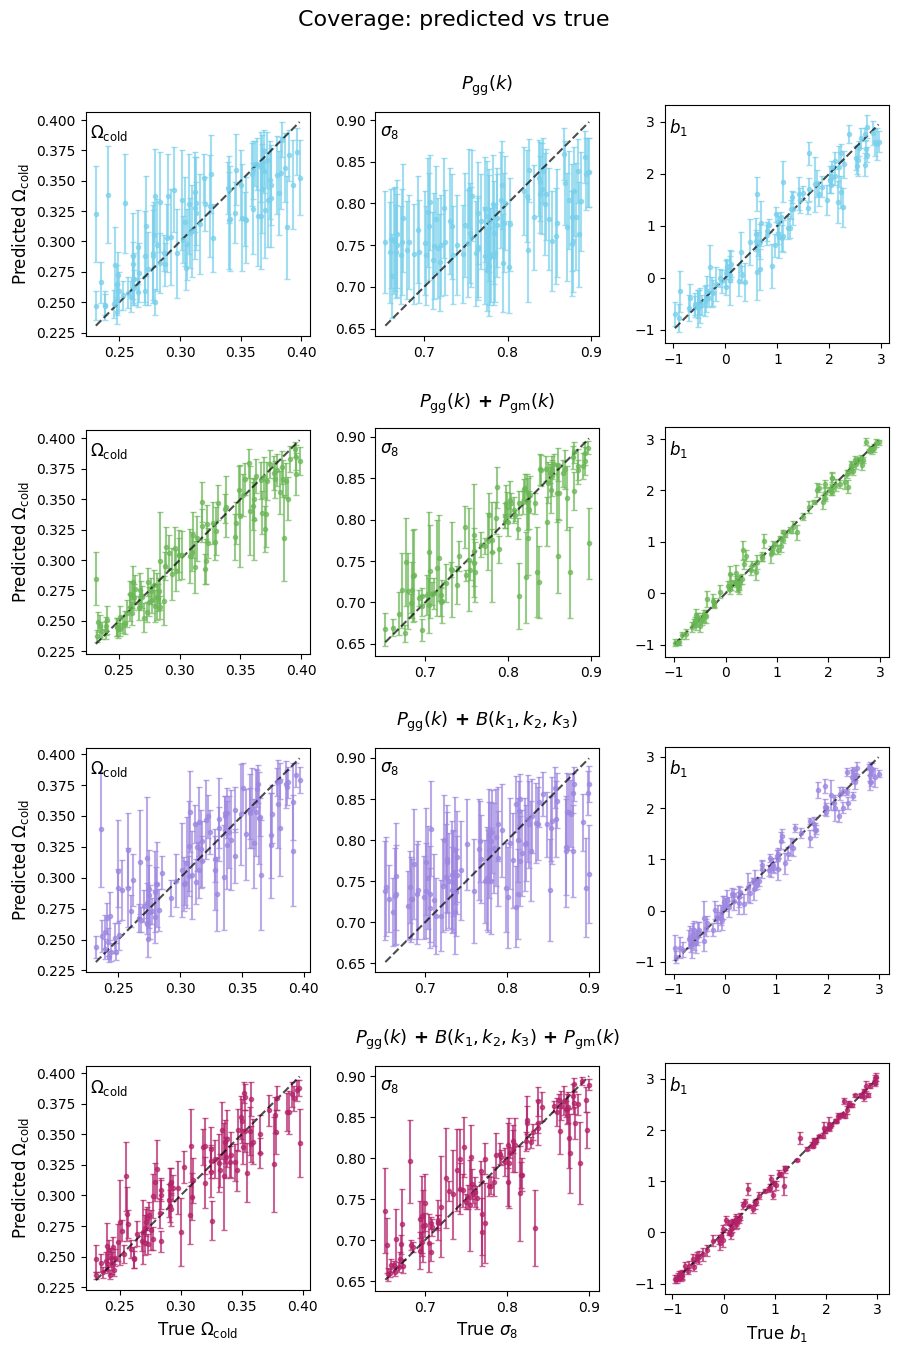

(<Figure size 900x1400 with 12 Axes>,
 array([[<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='Predicted $\\Omega_\\mathrm{cold}$'>, <Axes: >,
         <Axes: >],
        [<Axes: xlabel='True $\\Omega_\\mathrm{cold}$', ylabel='Predicted $\\Omega_\\mathrm{cold}$'>,
         <Axes: xlabel='True $\\sigma_{8}$'>, <Axes: xlabel='True $b_1$'>]],
       dtype=object))

In [10]:
plotter.plot_comp_mean_subplots_grid(
    stats_ok,
    theta_pred_arr, theta_true_arr, covs_pred_arr,
    param_names=param_names_key_rp,
    param_names_plot=param_names_key,
    param_label_dict=utils_plot.param_label_dict,
    color_arr=colors_ok, label_arr=labels_ok,
    alpha=0.7, N_plot=100, unreparameterize=True,
    title="Coverage: predicted vs true",
)

## 6. SHAMe test

OOD galaxy catalog ($\bar n = 0.00022\,h^3/\mathrm{Mpc}^3$). Contours for all fiducial statistics combinations.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


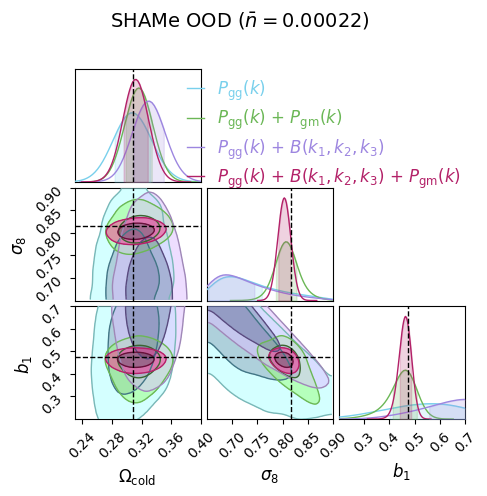

In [11]:
tags_inf, labels, colors, tags_test, keep, param_vary, theta_show = setup_shame_test()

plot_fiducial_contours(
    tags_inf, labels, colors, tags_test, keep,
    title=f"SHAMe OOD ($\\bar n=0.00022$)",
    theta_show=theta_show,
    extents=extents_narrow,
)

## 7. Convergence: $n_\mathrm{train}$ and $b_x$

Coverage-test marginal FoM / FoB vs $N_\mathrm{train} = n_\mathrm{cosmo} \times n_\mathrm{bias}$ ($= n_\mathrm{train} \times b_x$ on the grid). Curves connect fixed $n_\mathrm{cosmo}$ across $b_x$; opacity $\propto n_\mathrm{cosmo}$. Full grid: `2026-06-05_convergence_ntrain_bx.ipynb`.

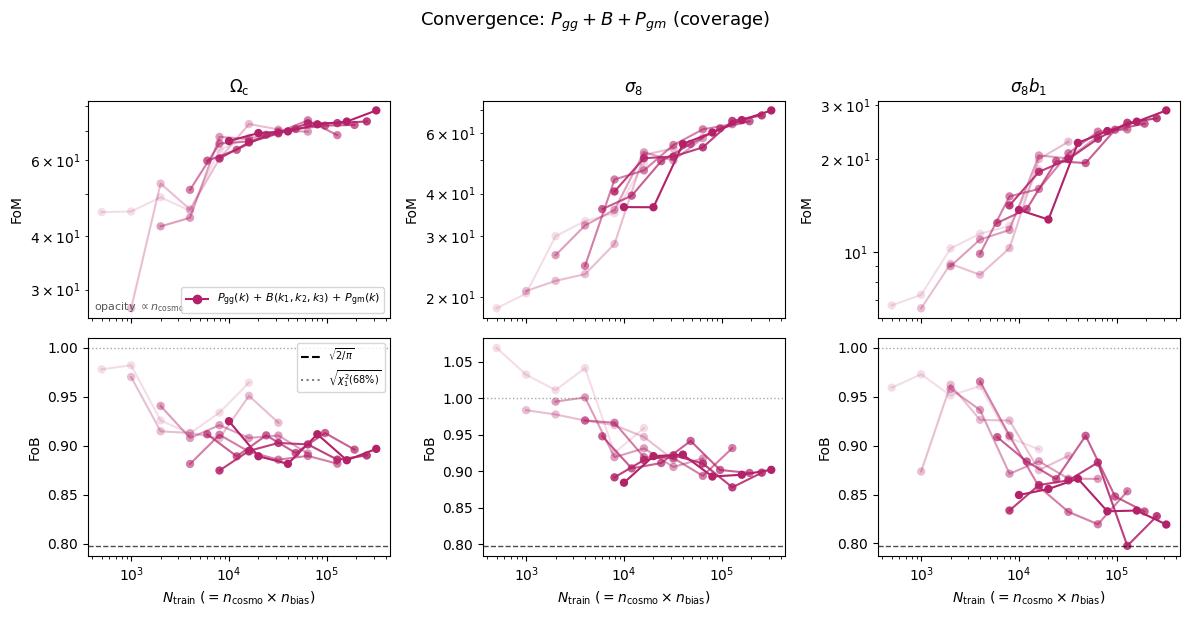

$P_\mathrm{gg}(k)$: 42 grid points loaded
Missing: $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$, bx=2, n_cosmo=4000
Missing: $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$, bx=16, n_cosmo=500
$P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$: 40 grid points loaded
Missing: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$, bx=4, n_cosmo=2000
Missing: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$, bx=4, n_cosmo=4000
$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$: 40 grid points loaded
$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$: 42 grid points loaded


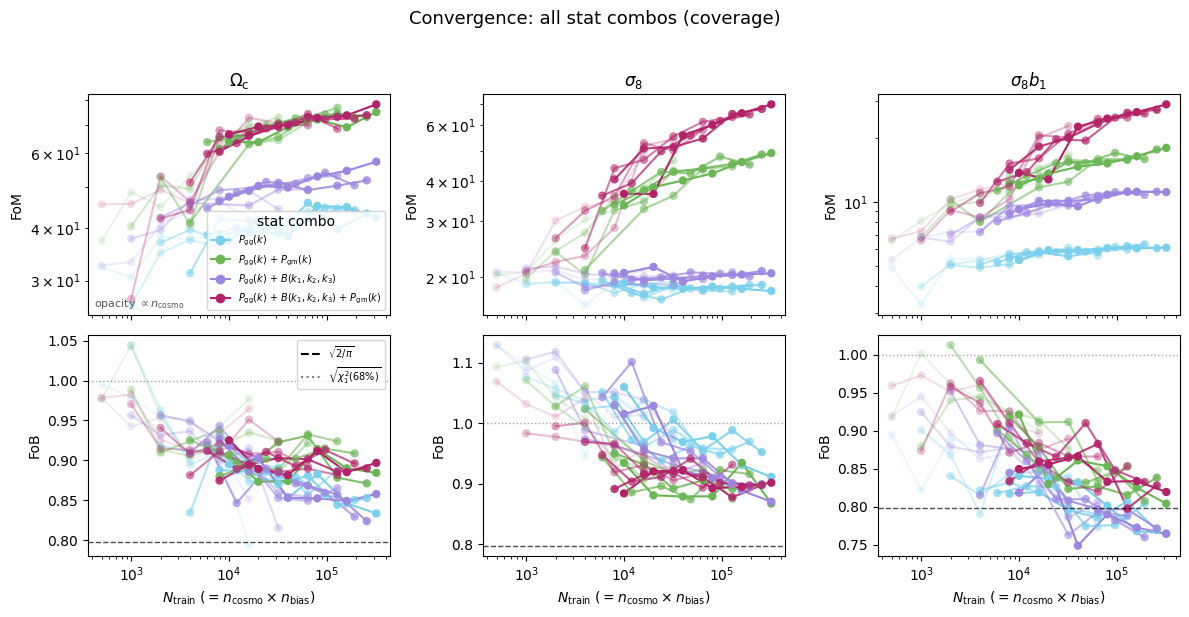

In [12]:
import pandas as pd
import utils_inference as ui
from scipy.stats import chi2

statistics_full = ["pk", "bispec", "pgm"]
tag_masks_full = "_kb0.25_kpgm0.25"
n_cosmo_arr = [500, 1000, 2000, 4000, 6000, 8000, 10000]
bx_arr = [1, 2, 4, 8, 16, 32]
N_COVERAGE = 1000

PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
FOB_KEYS = ["omega_m", "sigma8", "sigma8_b1"]
FOB_LABELS = {
    "omega_m": r"$\Omega_\mathrm{c}$",
    "sigma8": r"$\sigma_8$",
    "sigma8_b1": r"$\sigma_8 b_1$",
}
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8
NCOSMO_ALPHA_LO, NCOSMO_ALPHA_HI = 0.15, 1.0
XLABEL_NSIMS = r"$N_\mathrm{train}$ ($= n_\mathrm{cosmo} \times n_\mathrm{bias}$)"


def fob_chi2_sqrt_limit(ndims):
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


def compute_fob(theta_pred_row, cov, param_names, theta_true, param_vary):
    names = list(param_names)
    theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
    names_rep = list(names_rep)
    true_fob = np.array(
        [theta_true_rep[names_rep.index(pn)] for pn in PARAM_NAMES_FOB], dtype=float,
    )
    mu = np.array(
        [float(theta_pred_row[names.index(pn)]) for pn in PARAM_NAMES_FOB], dtype=float,
    )
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, logdet = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def compute_fom_key_block(cov, param_names):
    names = list(param_names)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = np.asarray(cov, dtype=float)[np.ix_(idx_fob, idx_fob)]
    fom_marg = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[key] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


def build_tag_inf_conv(bx_val, n_cosmo_val, statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}{TAG_PARAMS_TRAIN}"
        f"{TAG_BIASPARAMS_TRAIN}{TAG_NOISE_TRAIN}{tag_reparam}"
        f"_bx{bx_val}_ntrain{n_cosmo_val}{TAG_INF_BEST_SUFFIX}"
    )


def build_tag_test_conv(statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}"
        f"{TAG_PARAMS_TEST_COV}{TAG_BIASPARAMS_TEST_COV}{TAG_NOISE_TEST_COV}"
    )


def _coverage_samples_path(tag_inf, tag_test):
    base = dir_sbi / f"sbi{tag_inf}"
    fn = base / f"samples_test{tag_test}_pred.npy"
    if fn.is_file():
        return fn
    fn_ip = base / f"samples_test{tag_test}_pred_inprogress.npy"
    return fn_ip if fn_ip.is_file() else None


def _moments_from_samples_3d(samples_arr, param_names):
    theta_pred = np.mean(samples_arr, axis=0)
    covs_pred = np.array(
        [np.cov(samples_arr[:, i, :].T) for i in range(samples_arr.shape[1])]
    )
    return theta_pred, covs_pred, list(param_names)


def load_coverage_metrics(bx, n_cosmo, statistics, tag_masks, tag_test=None):
    if tag_test is None:
        tag_test = build_tag_test_conv(statistics, tag_masks)
    tag_inf = build_tag_inf_conv(bx, n_cosmo, statistics, tag_masks)
    fn = _coverage_samples_path(tag_inf, tag_test)
    if fn is None:
        return None
    samples_arr = np.load(fn)
    fn_pn = dir_sbi / f"sbi{tag_inf}" / "param_names.txt"
    if not fn_pn.is_file() or samples_arr.ndim != 3 or samples_arr.shape[1] == 0:
        return None
    param_names_all = np.loadtxt(fn_pn, dtype=str)
    n_obs = int(samples_arr.shape[1])
    theta_pred, covs_pred, param_names = _moments_from_samples_3d(samples_arr, param_names_all)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta_true_all = data_loader.load_theta_test(
        TAG_PARAMS_TEST_COV, TAG_BIASPARAMS_TEST_COV,
        cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
    )
    if theta_true_all.ndim == 1:
        theta_true_all = np.tile(theta_true_all, (n_obs, 1))
    n_use = min(n_obs, theta_true_all.shape[0], theta_pred.shape[0])
    theta_true_all = theta_true_all[:n_use]
    theta_pred = theta_pred[:n_use]
    covs_pred = covs_pred[:n_use]

    fob_lists = {key: [] for key in FOB_KEYS}
    fom_marg_lists = {key: [] for key in FOB_KEYS}
    for i in range(n_use):
        fob, _ = compute_fob(theta_pred[i], covs_pred[i], param_names, theta_true_all[i], param_vary)
        fom_marg, _ = compute_fom_key_block(covs_pred[i], param_names)
        for key in FOB_KEYS:
            fob_lists[key].append(fob[key])
            fom_marg_lists[key].append(fom_marg[key])

    row = {"bx": bx, "n_cosmo": n_cosmo, "n_sims": bx * n_cosmo, "n_cov": n_use}
    for key in FOB_KEYS:
        row[f"fom_{key}"] = float(np.nanmean(fom_marg_lists[key]))
        row[f"fob_{key}"] = float(np.nanmean(fob_lists[key]))
    return row


def collect_coverage_grid(statistics, tag_masks, n_cosmo_values, bx_values):
    tag_test = build_tag_test_conv(statistics, tag_masks)
    rows = []
    for bx in bx_values:
        for n_cosmo in n_cosmo_values:
            m = load_coverage_metrics(bx, n_cosmo, statistics, tag_masks, tag_test=tag_test)
            if m is None:
                print(f"Missing: {utils_plot.get_stat_label(statistics)}, bx={bx}, n_cosmo={n_cosmo}")
                continue
            rows.append(m)
    return pd.DataFrame(rows) if rows else pd.DataFrame()


def n_cosmo_alpha(n_cosmo, n_cosmo_values=None, lo=NCOSMO_ALPHA_LO, hi=NCOSMO_ALPHA_HI):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else n_cosmo_arr)
    if len(n_cosmo_values) == 1:
        return hi
    t = n_cosmo_values.index(int(n_cosmo)) / (len(n_cosmo_values) - 1)
    return lo + t * (hi - lo)


def _draw_nsims_curves(ax, df, y_col, color, *, n_cosmo_values=None, legend_label=None):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else df["n_cosmo"].unique())
    rgb = mcolors.to_rgb(color)
    if legend_label:
        ax.plot([], [], color=rgb, marker="o", ls="-", lw=1.5, markersize=6, label=legend_label)
    for n_cosmo in n_cosmo_values:
        grp = df[df["n_cosmo"] == n_cosmo].sort_values("n_sims")
        if grp.empty or y_col not in grp.columns:
            continue
        rgba = (*rgb, n_cosmo_alpha(n_cosmo, n_cosmo_values))
        if len(grp) >= 2:
            ax.plot(grp["n_sims"], grp[y_col], color=rgba, ls="-", lw=1.5, zorder=1)
        ax.scatter(
            grp["n_sims"], grp[y_col], c=[rgba] * len(grp),
            marker="o", s=36, linewidths=0, zorder=2,
        )


def plot_conv_fom_fob_nsims(
    df,
    color,
    title,
    *,
    legend_label=None,
    show_combo_legend=False,
    n_cosmo_values=None,
):
    if df.empty:
        print(f"No data for {title}")
        return
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else df["n_cosmo"].unique())
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    for ax, key in zip(axes[0], FOB_KEYS):
        _draw_nsims_curves(
            ax, df, f"fom_{key}", color,
            n_cosmo_values=n_cosmo_values, legend_label=legend_label if key == FOB_KEYS[0] else None,
        )
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        ax.set_xscale("log")
        if legend_label and key == FOB_KEYS[0]:
            ax.legend(fontsize=8, loc="best")
    for ax, key in zip(axes[1], FOB_KEYS):
        _draw_nsims_curves(ax, df, f"fob_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7)
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7)
        ax.set_ylabel("FoB")
        ax.set_xscale("log")
        if key == FOB_KEYS[0]:
            ax.legend(
                [plt.Line2D([0], [0], color="k", ls="--"), plt.Line2D([0], [0], color="gray", ls=":")],
                [r"$\sqrt{2/\pi}$", r"$\sqrt{\chi^2_1(68\%)}$"],
                fontsize=7, loc="best",
            )
    for ax in axes[1]:
        ax.set_xlabel(XLABEL_NSIMS)
    fig.suptitle(title, fontsize=13, y=1.02)
    axes[0, 0].text(
        0.02, 0.02, r"opacity $\propto n_\mathrm{cosmo}$",
        transform=axes[0, 0].transAxes, fontsize=8, color="0.35", va="bottom",
    )
    fig.tight_layout()
    plt.show()


def plot_conv_all_combos_nsims(df_all, title):
    if df_all.empty:
        print(f"No data for {title}")
        return
    labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    for ax, key in zip(axes[0], FOB_KEYS):
        for label, color in zip(labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == label]
            _draw_nsims_curves(
                ax, sub, f"fom_{key}", color, legend_label=label if key == FOB_KEYS[0] else None,
            )
        ax.set_title(FOB_LABELS[key])
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        ax.set_xscale("log")
        if key == FOB_KEYS[0]:
            ax.legend(fontsize=7, loc="best", title="stat combo")
    for ax, key in zip(axes[1], FOB_KEYS):
        for label, color in zip(labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == label]
            _draw_nsims_curves(ax, sub, f"fob_{key}", color)
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7)
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7)
        ax.set_ylabel("FoB")
        ax.set_xscale("log")
        if key == FOB_KEYS[0]:
            ax.legend(
                [plt.Line2D([0], [0], color="k", ls="--"), plt.Line2D([0], [0], color="gray", ls=":")],
                [r"$\sqrt{2/\pi}$", r"$\sqrt{\chi^2_1(68\%)}$"],
                fontsize=7, loc="best",
            )
    for ax in axes[1]:
        ax.set_xlabel(XLABEL_NSIMS)
    fig.suptitle(title, fontsize=13, y=1.02)
    axes[0, 0].text(
        0.02, 0.02, r"opacity $\propto n_\mathrm{cosmo}$",
        transform=axes[0, 0].transAxes, fontsize=8, color="0.35", va="bottom",
    )
    fig.tight_layout()
    plt.show()


# --- Full 3-stat combo ---
df_conv_full = collect_coverage_grid(statistics_full, tag_masks_full, n_cosmo_arr, bx_arr)
plot_conv_fom_fob_nsims(
    df_conv_full,
    COLORS_FID[3],
    r"Convergence: $P_{gg}+B+P_{gm}$ (coverage)",
    legend_label=utils_plot.get_stat_label(statistics_full),
)

# --- All fiducial stat combos ---
frames = []
for statistics, tag_masks, label in zip(STATISTICS_ARR_FID, TAGS_MASK_FID, [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]):
    df = collect_coverage_grid(statistics, tag_masks, n_cosmo_arr, bx_arr)
    if df.empty:
        print(f"No coverage grid for {label}")
        continue
    df = df.copy()
    df["stat_combo"] = label
    frames.append(df)
    print(f"{label}: {len(df)} grid points loaded")
df_conv_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
plot_conv_all_combos_nsims(df_conv_all, "Convergence: all stat combos (coverage)")

## 8. Scale dependence of constraints

Fixed-cosmo mean: overlay contours for increasing $k_\mathrm{max}$ cuts (bispec and PGM families).

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.2_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks

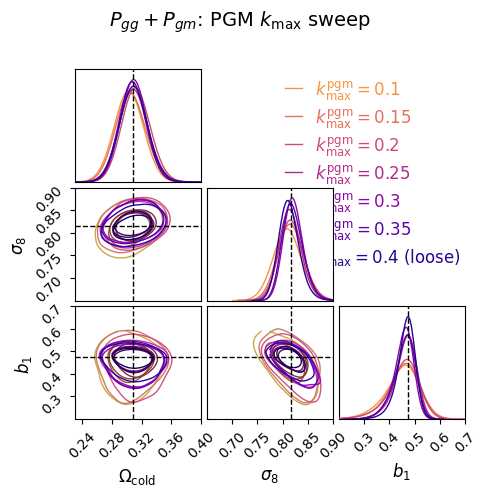

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.1_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.1_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.15_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.15_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.2_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.2_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchis

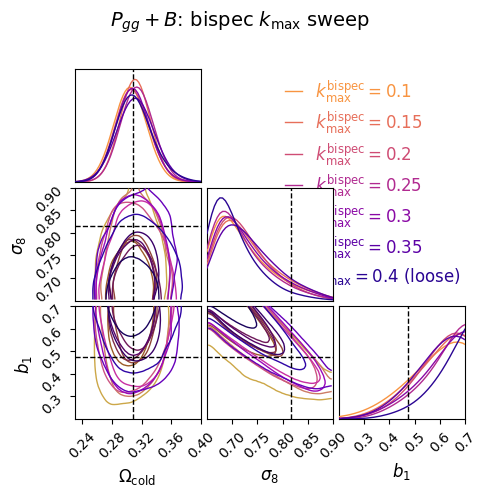

In [13]:
TAGS_KMAX_KPGM = ["_kpgm0.1", "_kpgm0.15", "_kpgm0.2", "_kpgm0.25", "_kpgm0.3", "_kpgm0.35", ""]
TAGS_KMAX_KB = ["_kb0.1", "_kb0.15", "_kb0.2", "_kb0.25", "_kb0.3", "_kb0.35", ""]
STAT_ROW_PGM = ["pk", "pgm"]
STAT_ROW_KB = ["pk", "bispec"]
STAT_ROW_BPGM = ["pk", "bispec", "pgm"]


def pp_colors(n):
    return [mcolors.to_hex(c) for c in plt.cm.plasma_r(np.linspace(0.25, 0.95, max(n, 1)))]


def kmax_label(tag_mask, family="pgm"):
    for part in tag_mask.split("_"):
        if family == "pgm" and part.startswith("kpgm"):
            return rf"$k_\mathrm{{max}}^\mathrm{{pgm}}={float(part[4:])}$"
        if family == "bispec" and part.startswith("kb"):
            return rf"$k_\mathrm{{max}}^\mathrm{{bispec}}={float(part[2:])}$"
    return rf"$k_\mathrm{{max}}={KMAX_LOOSE}$ (loose)"


def plot_kmax_sweep(statistics_row, tags_mask_list, title, theta_show, *, kmax_focus="pgm"):
    statistics_arr = [statistics_row] * len(tags_mask_list)
    tags_inf, labels, colors = setup_fiducial_inference()
    # replace with row-specific masks
    tags_inf, _, _, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN, statistics_arr=statistics_arr,
        bx=bx, tag_noise=TAG_NOISE_TRAIN, tag_reparam=tag_reparam,
        n_train=n_train, tags_mask=tags_mask_list,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    tag_stats = f'_{"_".join(statistics_row)}'
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats] * len(tags_mask_list),
        tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=tags_mask_list,
    )
    keep = samples_exist(tags_inf, tags_test)
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print(f"No samples for {title}")
        return
    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs], tags_test=[tags_test[i] for i in idxs],
        colors=pp_colors(len(idxs)),
        labels=[kmax_label(tags_mask_list[i], kmax_focus) for i in idxs],
        title=title, extents=extents_narrow, figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND, loc_legend=LOC_LEGEND, unreparameterize=True,
    )


_, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

plot_kmax_sweep(STAT_ROW_PGM, TAGS_KMAX_KPGM, r"$P_{gg}+P_{gm}$: PGM $k_\mathrm{max}$ sweep", theta_show, kmax_focus="pgm")
plot_kmax_sweep(STAT_ROW_KB, TAGS_KMAX_KB, r"$P_{gg}+B$: bispec $k_\mathrm{max}$ sweep", theta_show, kmax_focus="bispec")

---

## Appendix A. Mean vs individual realizations (fixed cosmo)

Compare inference on the **mean** statistic vs a single realization — should give consistent constraints.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30, tag_test=_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_pred.npy


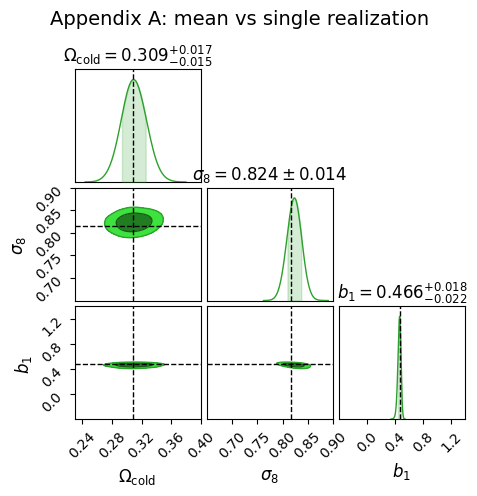

In [14]:
# Use full stat combo only; idx_obs=0 for both mean and single mock
statistics_row = ["pk", "bispec", "pgm"]
tag_masks_row = "_kb0.25_kpgm0.25"
tags_inf, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN, tag_biasparams=TAG_BIASPARAMS_TRAIN,
    statistics_arr=[statistics_row], bx=bx, tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam, n_train=n_train, tags_mask=[tag_masks_row],
)
tag_inf = tags_inf[0] + TAG_INF_BEST_SUFFIX
tag_stats = f'_{"_".join(statistics_row)}'
tag_test_mean = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[tag_masks_row],
)[0]
tag_test_single = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=[tag_stats],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test="",
    tags_mask_test=[tag_masks_row],
)[0]

_, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
    inf_methods=["sbi", "sbi"], tags_inf=[tag_inf, tag_inf],
    tags_test=[tag_test_mean, tag_test_single],
    colors=["#2ca02c", "#d62728"], labels=["mean", "single mock"],
    title="Appendix A: mean vs single realization",
    extents=extents_mid, figsize=FIGSIZE_CORNER, unreparameterize=True,
)

## Appendix B. Impact of noise

Compare noiseless vs noisy training on the fixed-cosmo mean test (pk only as baseline).

ERROR: missing samples (inf_method=sbi, tag_inf=_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30, tag_test=_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean): /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


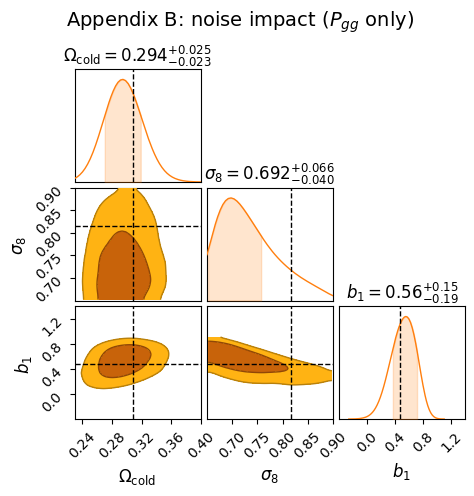

In [15]:
statistics_pk = [["pk"]]
tags_inf_noiseless, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams="_biasnest_p4_n320000", statistics_arr=statistics_pk,
    bx=bx, tag_noise=None, tag_reparam=tag_reparam, n_train=n_train, tags_mask=[""],
)
tags_inf_noisy, _, _, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode, tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN, statistics_arr=statistics_pk,
    bx=bx, tag_noise=TAG_NOISE_TRAIN, tag_reparam=tag_reparam, n_train=n_train, tags_mask=[""],
)
tags_inf_noiseless = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noiseless]
tags_inf_noisy = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noisy]

tag_test = utils_plot.setup_test_tags(
    data_mode=data_mode, tag_params_test=TAG_PARAMS_TEST_FIXED,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_FIXED, tag_stats_arr=["_pk"],
    tag_noise_test=TAG_NOISE_TEST_FIXED, tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
    tags_mask_test=[""],
)[0]

_, _, _, _, _, _, theta_show, _ = setup_fixed_mean_test()

plotter.plot_contours_inf(
    param_names=PARAM_NAMES_ZOOM, idx_obs=idx_obs, theta_obs_true=theta_show,
    inf_methods=["sbi", "sbi"], tags_inf=[tags_inf_noiseless[0], tags_inf_noisy[0]],
    tags_test=[tag_test, tag_test],
    colors=["#1f77b4", "#ff7f0e"], labels=["noiseless train", "noisy train"],
    title="Appendix B: noise impact ($P_{gg}$ only)",
    extents=extents_mid, figsize=FIGSIZE_CORNER, unreparameterize=True,
)

## Appendix C. Full posteriors (cosmic variance & SHAMe)

All varied parameters including $A_\mathrm{noise}$ parameters. Fiducial stat combos on fixed-cosmo mean and SHAMe.

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.2

Parameter b2 in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ is not constrained
Parameter An_b1 in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained


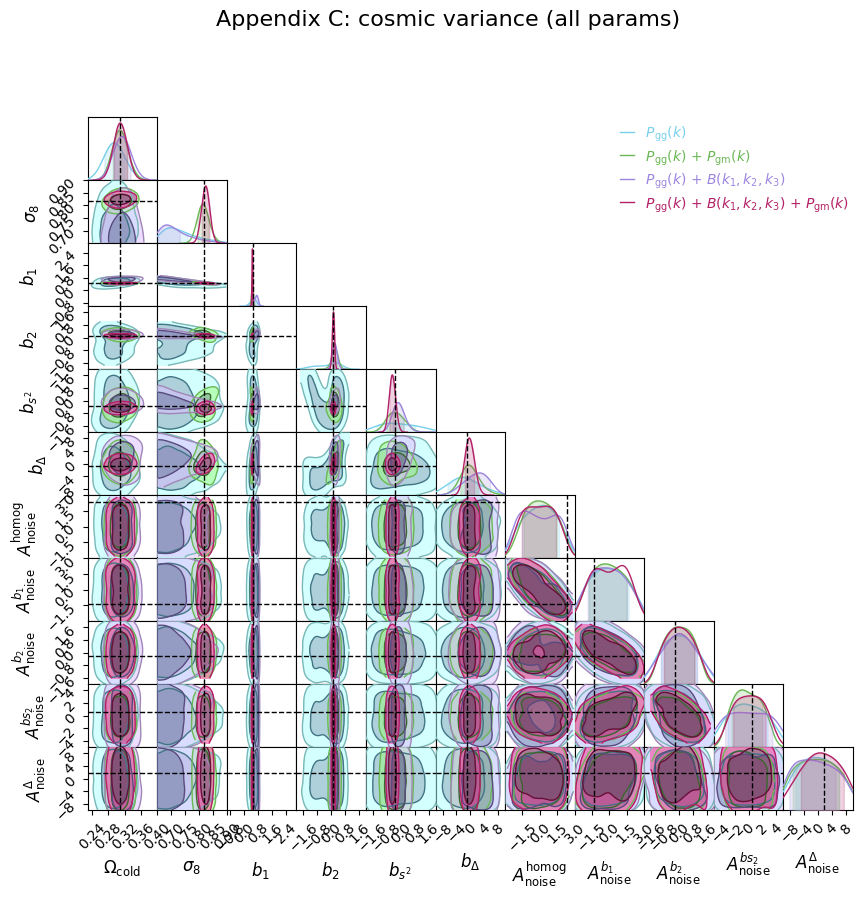

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


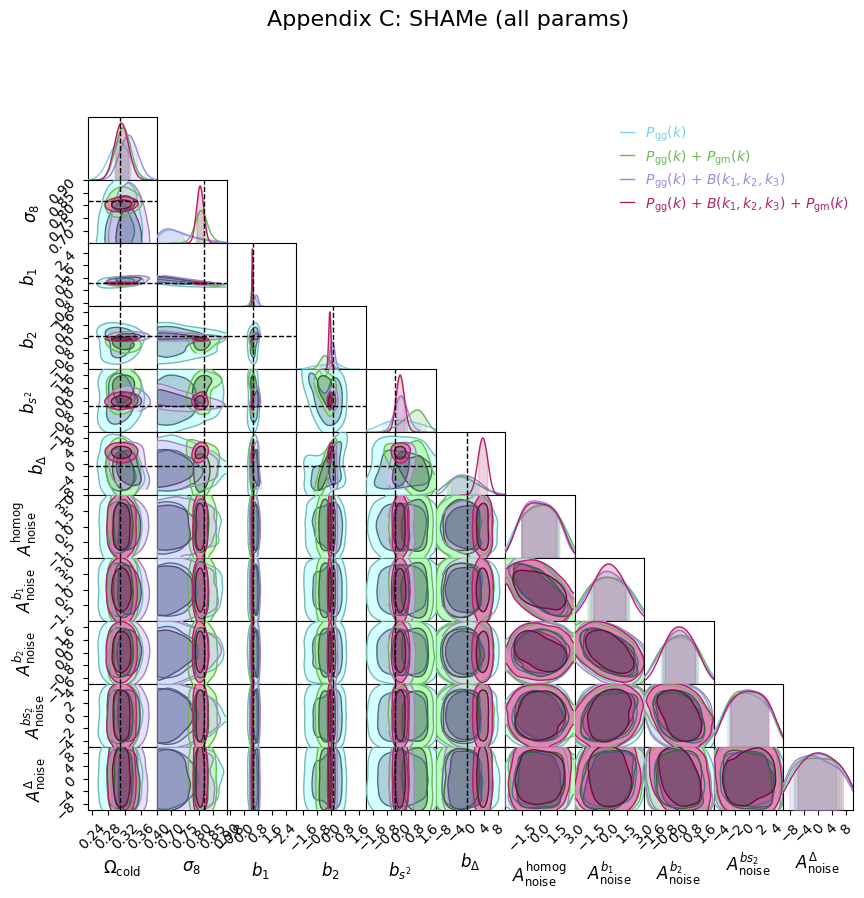

In [16]:
def plot_all_params(tags_inf, labels, colors, tags_test, keep, title, theta_obs, param_vary):
    idxs = [i for i, k in enumerate(keep) if k]
    if not idxs:
        print(f"No samples for {title}")
        return
    extents_all = {
        **genp.get_bounds("cosmo"), **genp.get_bounds("bias"),
        **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
    }
    plotter.plot_contours_inf(
        param_names=list(param_vary), idx_obs=idx_obs,
        theta_obs_true=np.asarray(theta_obs, dtype=float).reshape(-1),
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs], tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs], labels=[labels[i] for i in idxs],
        title=title, extents=extents_all, figsize=FIGSIZE_ALL_PARAMS,
        fontsize_legend=10, loc_legend=(1.02, 0.98), unreparameterize=True,
    )


tags_inf, labels, colors, tags_test, keep, theta_obs_full, _, param_vary = setup_fixed_mean_test()
plot_all_params(tags_inf, labels, colors, tags_test, keep,
                "Appendix C: cosmic variance (all params)", theta_obs_full, param_vary)

tags_inf, labels, colors, tags_test, keep, param_vary, _ = setup_shame_test()
theta_dict = data_loader.load_params_ood(DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME)
theta_shame_full = np.array([theta_dict.get(pn, np.nan) for pn in param_vary])
plot_all_params(tags_inf, labels, colors, tags_test, keep,
                "Appendix C: SHAMe (all params)", theta_shame_full, param_vary)